In [1]:
from reflect.components.flow_world_model.dynamic_model import DynamicFlowModel, DynamicAttentionalFlowModel
from reflect.components.flow_world_model.world_model_actor import WorldModelActor
from reflect.components.flow_world_model.world_model import WorldModel
from reflect.data.loader import EnvDataLoader
from reflect.components.models.actor import Actor

from tqdm import tqdm
from livelossplot import PlotLosses
import gymnasium as gym
from dataclasses import asdict
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.optim as optim

/Users/alexathorne/development/personal/world-model-rl/venv/lib/python3.10/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment InvertedPendulum-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


In [2]:
env = gym.make('Pendulum-v1')

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

actor = Actor(
    input_dim=state_dim,
    output_dim=action_dim,
    bound=env.action_space.high,
    num_layers=3,
    hidden_dim=256,
)

world_model_actor = WorldModelActor(
    actor=actor,
)

env_data_loader = EnvDataLoader(
    num_time_steps=10,
    state_shape=(state_dim,),
    policy=world_model_actor,
    env=env,
    use_imgs_as_states=False,
)


In [3]:
for _ in tqdm(range(10)):
    env_data_loader.perform_rollout()

100%|██████████| 10/10 [00:01<00:00,  7.04it/s]


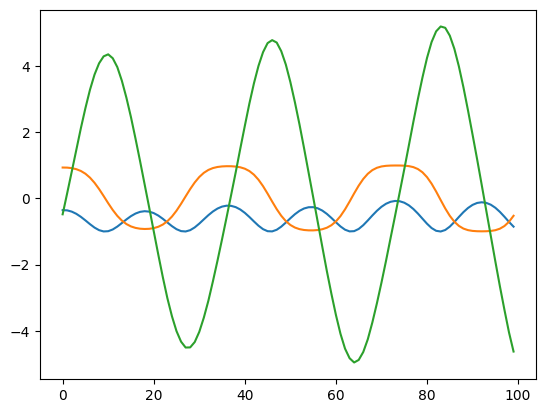

In [4]:
import matplotlib.pyplot as plt
plt.plot(env_data_loader.state_buffer[3][:, 0])
plt.plot(env_data_loader.state_buffer[3][:, 1])
plt.plot(env_data_loader.state_buffer[3][:, 2])
plt.show()

In [5]:
state_dim = 3+1+1
action_dim = 1

dynamic_model = DynamicFlowModel(
    input_dim=state_dim,
    conditioning_dim=3*(state_dim + action_dim),
    output_dim=state_dim,
    time_embed_dim=16,
    hidden_dim=128,
    depth=2,
    use_layer_norm=True,
    num_positions=3,
)

world_model = WorldModel(
    dynamic_model=dynamic_model,
    observation_dim=state_dim-2,
    action_dim=action_dim,
    environment_action_bound=env.action_space.high,
)

# dynamic_model = DynamicAttentionalFlowModel(
#     input_dim=state_dim,
#     conditioning_dim=state_dim + action_dim,
#     output_dim=state_dim,
#     num_heads=4,
#     hidden_dim=256,
#     depth=2,
#     use_layer_norm=True,
#     num_positions=3,
# )

# world_model = WorldModel(
#     dynamic_model=dynamic_model,
#     observation_dim=state_dim-2,
#     action_dim=action_dim,
#     environment_action_bound=env.action_space.high,
# )


In [6]:
plot_losses = PlotLosses(
  groups={
    'flow_loss': ['flow_loss'],
    'rel_err': ['rel_err'],
  },
)

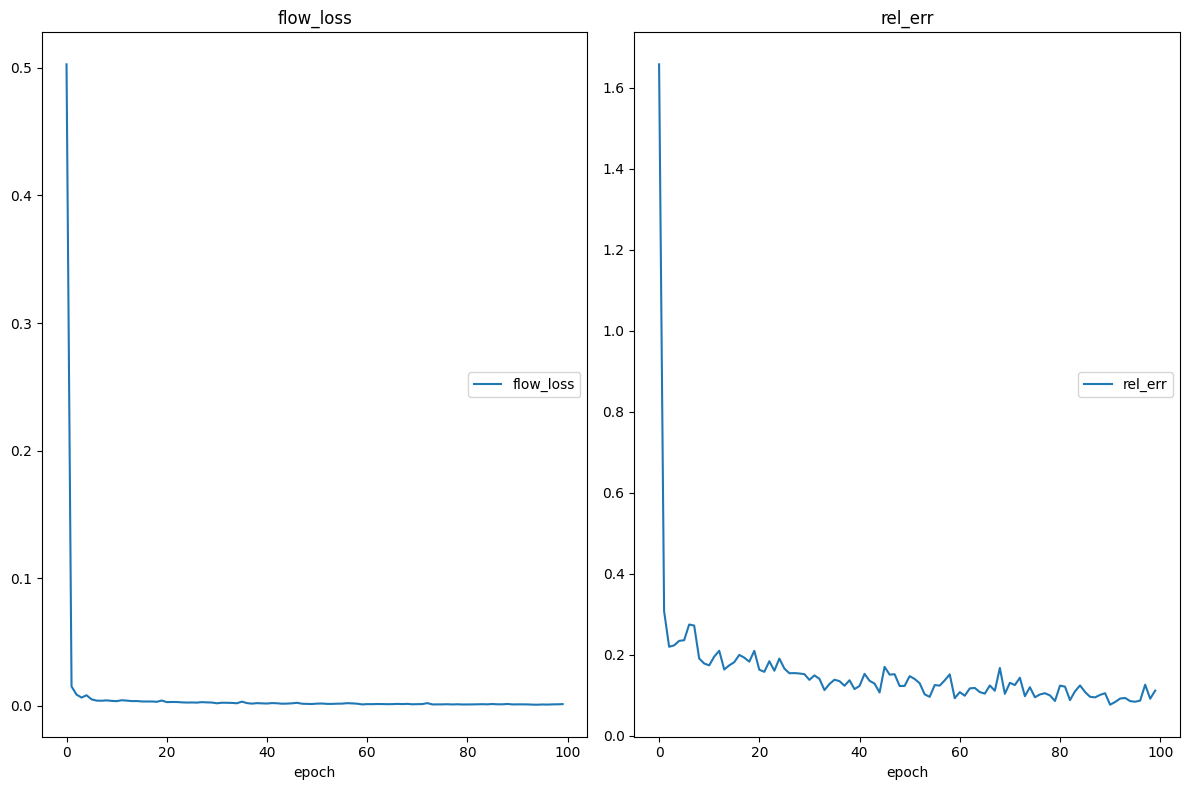

flow_loss
	flow_loss        	 (min:    0.001, max:    0.503, cur:    0.001)
rel_err
	rel_err          	 (min:    0.076, max:    1.658, cur:    0.111)


In [7]:
total_loss = 0
total_rel_err = 0
update_every = 100
for epoch in range(10_000):
    env_data_loader.perform_rollout()
    _, _, o, a, r, d = env_data_loader.sample(
        batch_size=256,
        num_time_steps=4
    )
    losses = world_model.update(o, a, r, d)
    losses = asdict(losses)
    total_loss += losses['flow_loss']
    total_rel_err += losses['rel_err']
    if epoch % update_every == 0:        
        plot_losses.update(losses)
        plot_losses.send()
        total_loss = 0
        total_rel_err = 0


In [21]:
for i in tqdm(range(64)): 
    env_data_loader.perform_rollout()

100%|██████████| 64/64 [00:10<00:00,  6.28it/s]


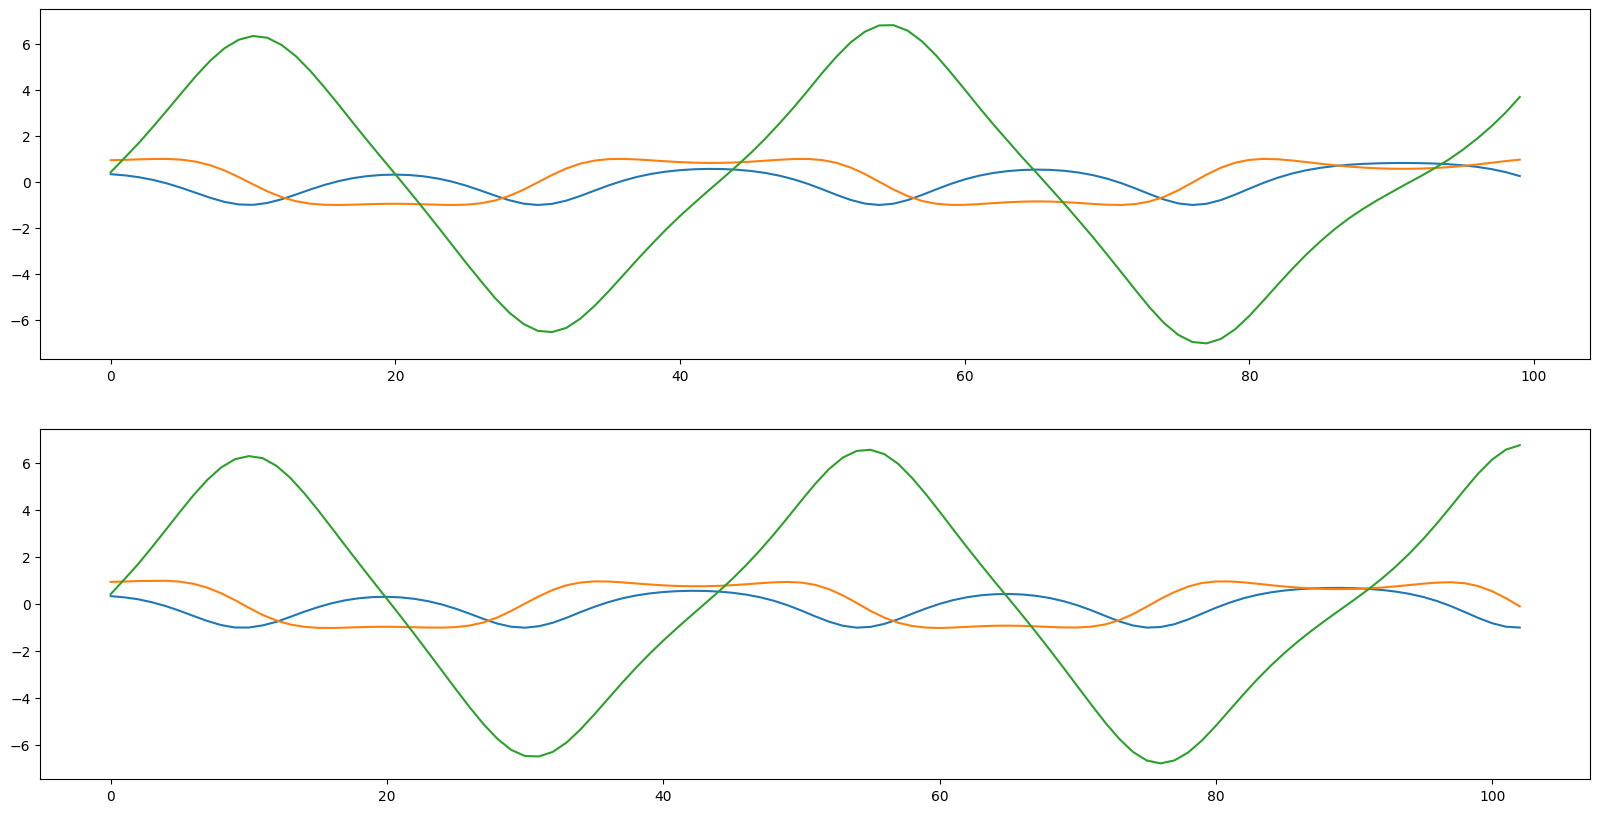

In [32]:
import matplotlib.pyplot as plt
import random
batch_size=0
traj_i = random.randint(0, env_data_loader.num_runs - 1 - batch_size)

o = env_data_loader.state_buffer[traj_i][None, :, :]
a = env_data_loader.action_buffer[traj_i][None, :, :]
r = env_data_loader.reward_buffer[traj_i][None, :, None]
d = env_data_loader.done_buffer[traj_i][None, :, None]

img_o, img_a, img_r, img_d = world_model.get_imagined_rollout(
    o[:, :3], a[:, :3], r[:, :3], d[:, :3],
    actor,
    num_steps=100,
    num_flow_steps=2,
    noise_scale=0.0
)

img_o = img_o.detach()
fig, axs = plt.subplots(nrows=2, figsize=(20, 10))
axs[0].plot(o[0, :, 0])
axs[0].plot(o[0, :, 1])
axs[0].plot(o[0, :, 2])
axs[1].plot(img_o[0, :, 0])
axs[1].plot(img_o[0, :, 1])
axs[1].plot(img_o[0, :, 2])
plt.show()